## **Analisis Suhu Rata - rata Harian Singapura**

* Muhammad Khaira Rahmadya Nauval (23/521078/TK/57466)
* Polikarpus Arya Pradhanika (23/512404/TK/56325)

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from Regression import PolynomialRegression

## **Membuka Dataset**

In [24]:
data = pd.read_csv("HistoricalDailyWeatherRecords.csv")

# Cek struktur data
data.head()

,date,station,daily_rainfall_total,highest_30_min_rainfall,highest_60_min_rainfall,highest_120_min_rainfall,mean_temperature,maximum_temperature,minimum_temperature,mean_wind_speed,max_wind_speed
0,2009-01-01,Admiralty,na,na,na,na,na,na,na,na,na
1,2009-01-02,Admiralty,na,na,na,na,na,na,na,na,na
2,2009-01-03,Admiralty,na,na,na,na,na,na,na,na,na
3,2009-01-04,Admiralty,na,na,na,na,na,na,na,na,na
4,2009-01-05,Admiralty,na,na,na,na,na,na,na,na,na


In [25]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2859 entries, 0 to 2858
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   date                      2859 non-null   object
 1   station                   2859 non-null   object
 2   daily_rainfall_total      2859 non-null   object
 3   highest_30_min_rainfall   2859 non-null   object
 4   highest_60_min_rainfall   2859 non-null   object
 5   highest_120_min_rainfall  2859 non-null   object
 6   mean_temperature          2859 non-null   object
 7   maximum_temperature       2859 non-null   object
 8   minimum_temperature       2859 non-null   object
 9   mean_wind_speed           2859 non-null   object
 10  max_wind_speed            2859 non-null   object
dtypes: object(11)
memory usage: 245.8+ KB


Terlihat bahwa jumlah data adalah 2859 baris

## 🔍 **Data Exploration**

In [26]:
# Cek missing values
# data = data[2800:]
data.replace('na', np.nan, inplace=True) # Mengubah data dengan value 'na' menjadi null value yang bisa dibaca python
print(data.isnull().sum())

date                           0
station                        0
daily_rainfall_total         105
highest_30_min_rainfall     1755
highest_60_min_rainfall     1755
highest_120_min_rainfall    1755
mean_temperature             139
maximum_temperature          115
minimum_temperature          115
mean_wind_speed               96
max_wind_speed                97
dtype: int64


Terlihat bahwa terdapat banyak data yang null pada kolom `highest_30_min_rainfall`, `highest_60_min_rainfall`, dan `highest_120_min_rainfall` yaitu mencapai 1755 data.

In [27]:
# Cek tipe data

print(data.dtypes)

date                        object
station                     object
daily_rainfall_total        object
highest_30_min_rainfall     object
highest_60_min_rainfall     object
highest_120_min_rainfall    object
mean_temperature            object
maximum_temperature         object
minimum_temperature         object
mean_wind_speed             object
max_wind_speed              object
dtype: object


Terlihat bahwa tipe data setiap data masih berupa object. Untuk itu, kita perlu mengubah tipe data nya sesuai dengan data.
Kita akan menggunakan tipe data
* datetime untuk kolom date
* string untuk kolom station
* number untuk kolom lainnya

In [28]:
# Karena datatype masih tidak cocok, maka diconvert sesuai yang tertulis di website
for col in data.columns:
    if col == 'date':
        data['date'] = pd.to_datetime(data['date'], format='%Y-%m-%d', errors='coerce')
    elif col == 'station':
        data['station'] = data['station'].astype(str)
    else:
        data[col] = pd.to_numeric(data[col], errors='coerce')

print(data.dtypes)

date                        datetime64[ns]
station                             object
daily_rainfall_total               float64
highest_30_min_rainfall            float64
highest_60_min_rainfall            float64
highest_120_min_rainfall           float64
mean_temperature                   float64
maximum_temperature                float64
minimum_temperature                float64
mean_wind_speed                    float64
max_wind_speed                     float64
dtype: object


Selanjutnya kita visualisasikan data kita

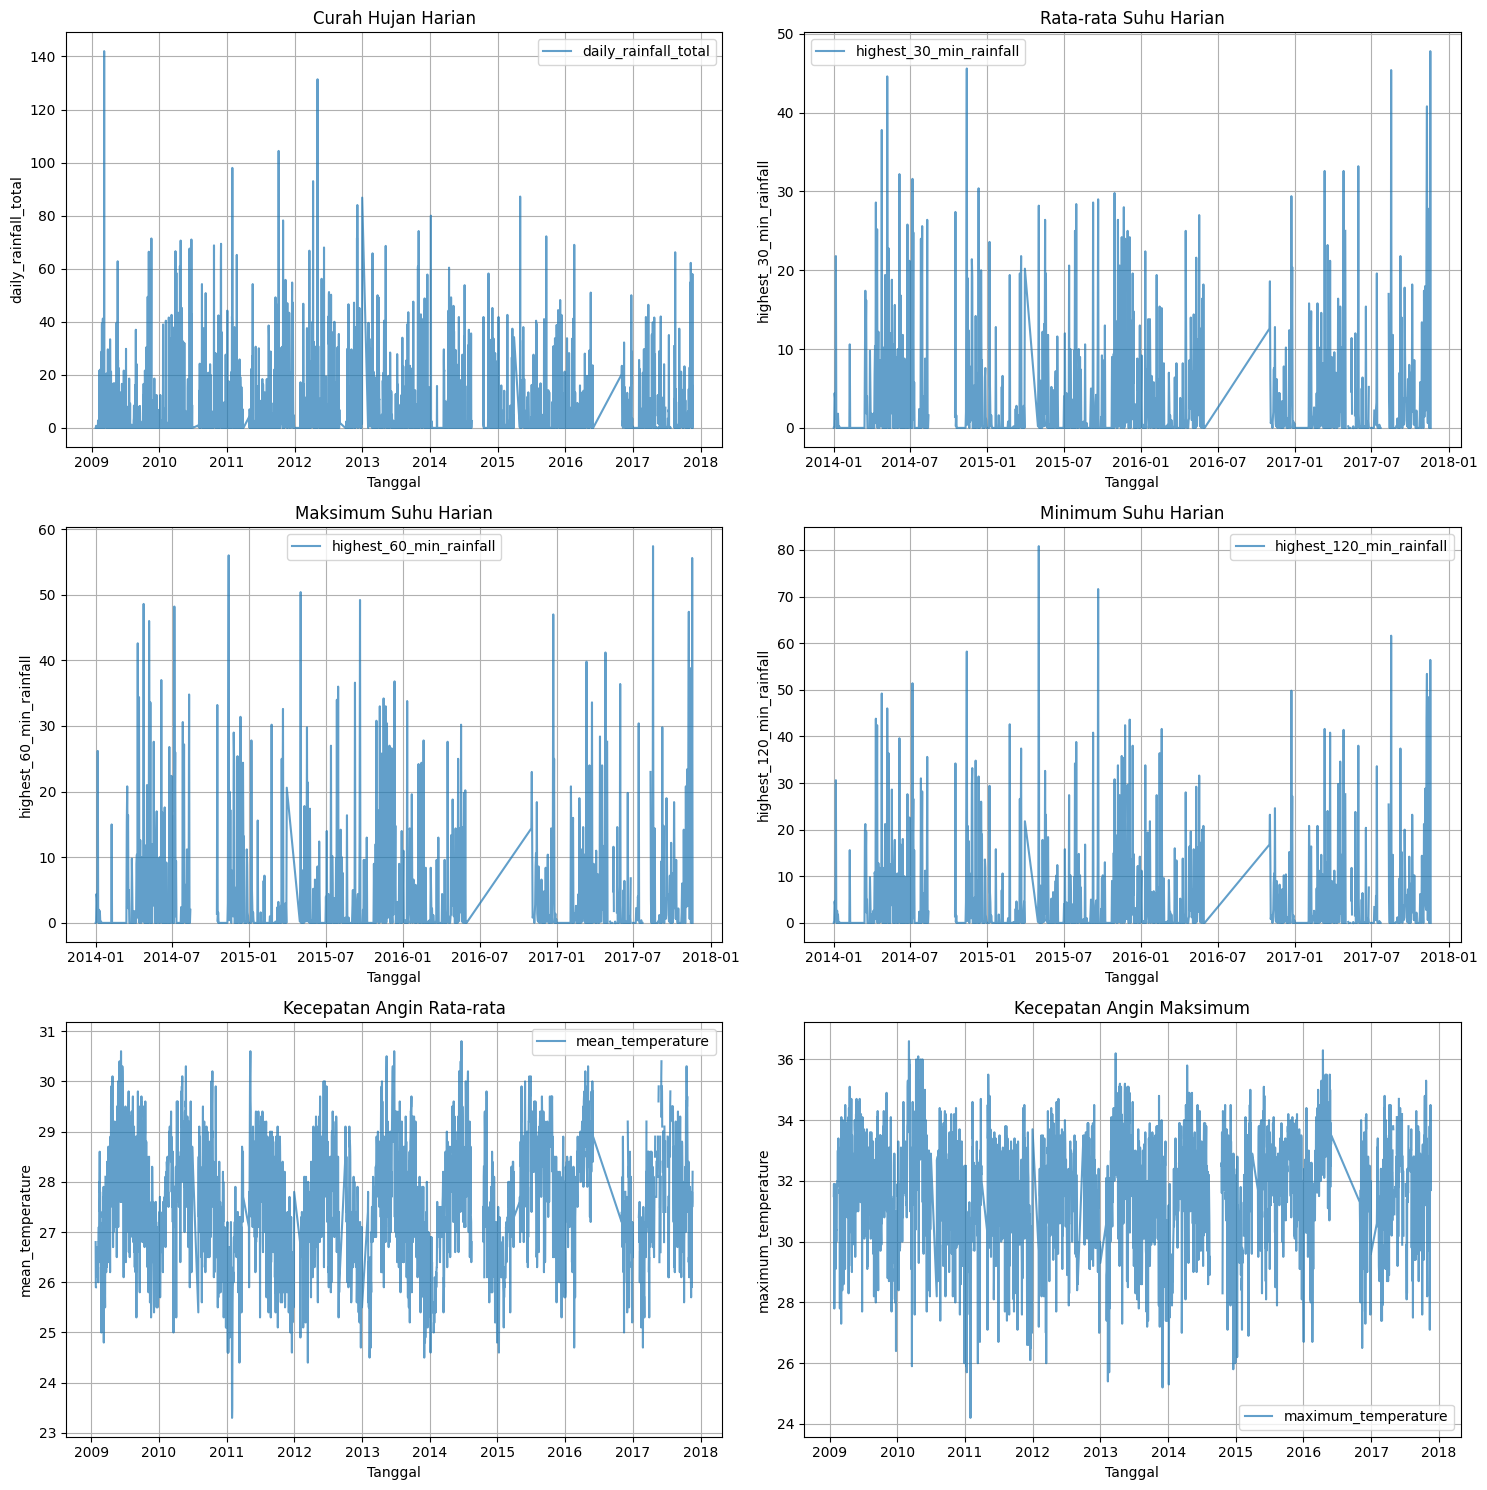

In [29]:
fig, axes = plt.subplots(3, 2, figsize=(15, 15))  # Create a 3x2 grid of subplots

numerical_columns = data.select_dtypes(include=[np.number]).columns.tolist()
columns_to_plot = numerical_columns  # Use the numerical columns for plotting
titles = [
    "Curah Hujan Harian",
    "Rata-rata Suhu Harian",
    "Maksimum Suhu Harian",
    "Minimum Suhu Harian",
    "Kecepatan Angin Rata-rata",
    "Kecepatan Angin Maksimum",
]

# data_clean = data_clean[len(data_clean) - 30:]  # Select the last 90 days of data
# monthly_data2 = monthly_data2[len(monthly_data2) - 90:]

for ax, col, title in zip(axes.flatten(), columns_to_plot, titles):
    ax.plot(data['date'], data[col], label=col, alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel("Tanggal")
    ax.set_ylabel(col)
    ax.legend()
    ax.grid()

plt.tight_layout()  # Adjust spacing between subplots
plt.show()

Cari tahu mean, min, quartil 1, quartil 2, quatil 3, max, dan standar deviasi dari setiap kolom

In [30]:
data.describe()

,date,daily_rainfall_total,highest_30_min_rainfall,highest_60_min_rainfall,highest_120_min_rainfall,mean_temperature,maximum_temperature,minimum_temperature,mean_wind_speed,max_wind_speed
count,2859,2754.000000,1104.000000,1104.000000,1104.000000,2720.000000,2744.000000,2744.000000,2763.000000,2762.000000
mean,2013-04-19 15:08:07.303252736,6.591903,3.668478,4.478080,4.993569,27.632059,31.749052,24.959111,7.846073,34.689066
min,2009-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,23.300000,24.200000,21.600000,3.700000,11.500000
25%,2011-01-16 12:00:00,0.000000,0.000000,0.000000,0.000000,26.800000,30.700000,24.200000,6.100000,28.400000
50%,2013-05-02 00:00:00,0.200000,0.200000,0.200000,0.200000,27.600000,32.000000,24.900000,7.100000,33.500000
75%,2015-06-15 12:00:00,6.800000,3.850000,4.400000,5.000000,28.500000,33.000000,25.700000,8.900000,39.200000
max,2017-11-30 00:00:00,142.000000,47.800000,57.400000,80.800000,30.800000,36.600000,28.500000,18.700000,86.800000
std,NaN,13.335983,7.119767,8.947346,10.102011,1.186947,1.772685,1.205388,2.437322,8.537456


## 🧹 **Data Cleaning**

Untuk highest_30_min_rainfall, highest_60_min_rainfall, dan highest_120_min_rainfall akan kita hapus karena terlalu banyak data yang hilang

In [31]:
removed_columns = ['highest_30_min_rainfall', 'highest_60_min_rainfall', 'highest_120_min_rainfall']
data_clean = data.drop(columns=removed_columns)
data_clean.head()

,date,station,daily_rainfall_total,mean_temperature,maximum_temperature,minimum_temperature,mean_wind_speed,max_wind_speed
0,2009-01-01,Admiralty,NaN,NaN,NaN,NaN,NaN,NaN
1,2009-01-02,Admiralty,NaN,NaN,NaN,NaN,NaN,NaN
2,2009-01-03,Admiralty,NaN,NaN,NaN,NaN,NaN,NaN
3,2009-01-04,Admiralty,NaN,NaN,NaN,NaN,NaN,NaN
4,2009-01-05,Admiralty,NaN,NaN,NaN,NaN,NaN,NaN


Untuk sisanya, akan kita isi dengan methode interpolasi linear. Ini dilakukan karena data berupa time series

In [32]:
numerical_columns = data_clean.select_dtypes(include=[np.number]).columns.tolist()
data_clean[numerical_columns] = data_clean[numerical_columns].interpolate(method='linear', order=3)
data_clean.isnull().sum()

date                     0
station                  0
daily_rainfall_total    21
mean_temperature        23
maximum_temperature     21
minimum_temperature     21
mean_wind_speed         21
max_wind_speed          21
dtype: int64

Terlihat masih ada beberapa baris dengan null value pada beberapa kolom pertama dan terakhir pada data. Baris - baris ini akan kita hapus

In [33]:
# Hapus baris di awal dan akhir yang memiliki nilai null
data_clean = data_clean.dropna()
data_clean.head()

,date,station,daily_rainfall_total,mean_temperature,maximum_temperature,minimum_temperature,mean_wind_speed,max_wind_speed
23,2009-01-24,Admiralty,0.0,26.80,31.4,24.4,11.7,38.2
24,2009-01-25,Admiralty,0.8,25.90,27.8,24.4,12.7,38.2
25,2009-01-26,Admiralty,0.0,25.90,29.6,23.7,12.4,42.5
26,2009-01-27,Admiralty,0.0,26.25,30.2,23.7,10.4,38.9
27,2009-01-28,Admiralty,0.0,26.60,31.9,23.7,10.3,32.4


Selanjutnya, kita akan menghapus outliers untuk meningkatkan performa model

In [34]:
# Menghapus outliers menggunakan metode IQR
Q1 = data_clean[numerical_columns].quantile(0.25)
Q3 = data_clean[numerical_columns].quantile(0.75)
IQR = Q3 - Q1

# Menentukan batas bawah dan atas
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Menyaring data untuk menghapus outliers
data_clean = data_clean[~((data_clean[numerical_columns] < lower_bound) | (data_clean[numerical_columns] > upper_bound)).any(axis=1)]

# Menampilkan data setelah penghapusan outliers
data_clean.head()

,date,station,daily_rainfall_total,mean_temperature,maximum_temperature,minimum_temperature,mean_wind_speed,max_wind_speed
23,2009-01-24,Admiralty,0.0,26.80,31.4,24.4,11.7,38.2
24,2009-01-25,Admiralty,0.8,25.90,27.8,24.4,12.7,38.2
25,2009-01-26,Admiralty,0.0,25.90,29.6,23.7,12.4,42.5
26,2009-01-27,Admiralty,0.0,26.25,30.2,23.7,10.4,38.9
27,2009-01-28,Admiralty,0.0,26.60,31.9,23.7,10.3,32.4


Kemudian, akan kita visualisasikan lagi data setelah dibersihkan

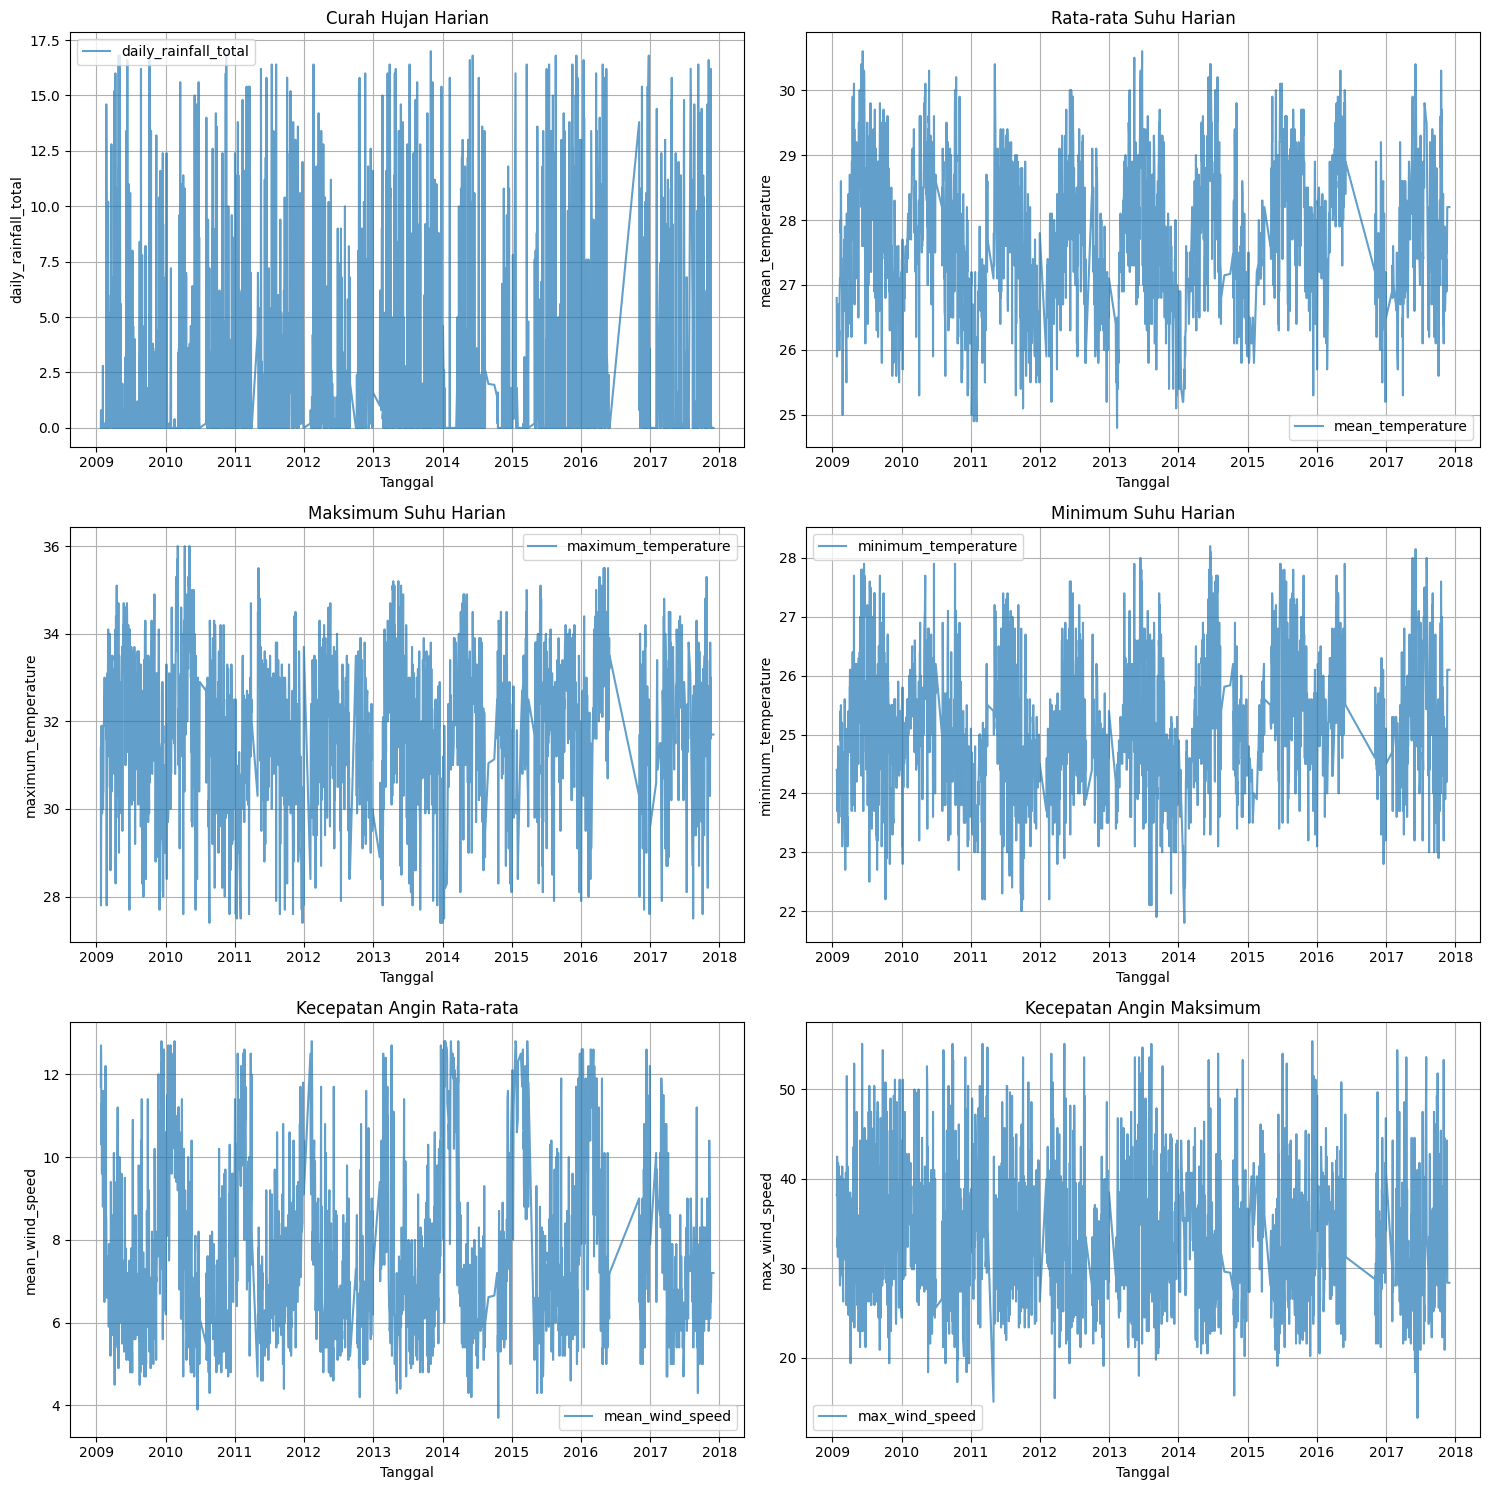

In [35]:
fig, axes = plt.subplots(3, 2, figsize=(15, 15))  # Create a 3x2 grid of subplots

columns_to_plot = numerical_columns  # Use the numerical columns for plotting
titles = [
    "Curah Hujan Harian",
    "Rata-rata Suhu Harian",
    "Maksimum Suhu Harian",
    "Minimum Suhu Harian",
    "Kecepatan Angin Rata-rata",
    "Kecepatan Angin Maksimum",
]

# data_clean = data_clean[len(data_clean) - 30:]  # Select the last 90 days of data
# monthly_data2 = monthly_data2[len(monthly_data2) - 90:]

for ax, col, title in zip(axes.flatten(), columns_to_plot, titles):
    ax.plot(data_clean['date'], data_clean[col], label=col, alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel("Tanggal")
    ax.set_ylabel(col)
    ax.legend()
    ax.grid()

plt.tight_layout()  # Adjust spacing between subplots
plt.show()

## 🔨 **Pembangunan Model**

In [36]:
def split_data(data, target, test_size=0.2):
    """
    Splits the data into training and testing sets.
    
    Parameters:
    - data: DataFrame to be split
    - test_size: Proportion of the data to be used for testing
    
    Returns:
    - train_data: Training set
    - test_data: Testing set
    """
    train_size = int(len(data) * (1 - test_size))
    train_data = data[:train_size]
    test_data = data[train_size:]
    
    X_train = train_data.drop(columns=[target])
    y_train = train_data[target]
    X_test = test_data.drop(columns=[target])
    y_test = test_data[target]

    return X_train, y_train, X_test, y_test

Akan kita hapus kolom yang tidak akan kita gunakan untuk membangun model. Yakni kolom date dan station.

Ini karena tipe data date pada datetime dan string pada station cukup sulit untuk diimplementasikan pada regresi

In [37]:
final_data = data_clean.drop(['date', 'station'], axis=1)  # Drop non-numeric columns for regression
X_train, y_train, X_test, y_test = split_data(final_data, target="mean_temperature", test_size=0.2) # split data into train and test set

Mencoba menggunkan LinearRegression

In [38]:
# model = SinusoidalRegression(max_freq=50)

print("""
--------------------
MODEL REGRESI LINEAR
--------------------
      """)
model = PolynomialRegression()
model.fit(X_train, y_train, 1)
evaluation = model.evaluate_all(X_train, y_train)
y_pred = model.getAllPrediction(X_test)
print("TRAIN EVALUATION")
print("R2 = {:.4f}".format(evaluation['R2']))
print("MSE = {:.4f}".format(evaluation['MSE']))
print("MAE = {:.4f}".format(evaluation['MAE']))
print()
evaluation = model.evaluate_all(X_test, y_test)
print("TEST EVALUATION")
print("R2 = {:.4f}".format(evaluation['R2']))
print("MSE = {:.4f}".format(evaluation['MSE']))
print("MAE = {:.4f}".format(evaluation['MAE']))



--------------------
MODEL REGRESI LINEAR
--------------------
      
TRAIN EVALUATION
R2 = 0.7937
MSE = 0.2627
MAE = 0.3998

TEST EVALUATION
R2 = 0.7288
MSE = 0.2698
MAE = 0.3940


In [39]:
# model = SinusoidalRegression(max_freq=50)

print("""
-------------------------------
MODEL REGRESI POLINOMIAL ORDE 2
-------------------------------
      """)
model = PolynomialRegression()
model.fit(X_train, y_train, 2)
evaluation = model.evaluate_all(X_train, y_train)
y_pred = model.getAllPrediction(X_test)
print("TRAIN EVALUATION")
print("R2 = {:.4f}".format(evaluation['R2']))
print("MSE = {:.4f}".format(evaluation['MSE']))
print("MAE = {:.4f}".format(evaluation['MAE']))
print()
evaluation = model.evaluate_all(X_test, y_test)
print("TEST EVALUATION")
print("R2 = {:.4f}".format(evaluation['R2']))
print("MSE = {:.4f}".format(evaluation['MSE']))
print("MAE = {:.4f}".format(evaluation['MAE']))



-------------------------------
MODEL REGRESI POLINOMIAL ORDE 2
-------------------------------
      
TRAIN EVALUATION
R2 = 0.8182
MSE = 0.2315
MAE = 0.3710

TEST EVALUATION
R2 = 0.7343
MSE = 0.2643
MAE = 0.3887


In [40]:
# model = SinusoidalRegression(max_freq=50)

print("""
-------------------------------
MODEL REGRESI POLINOMIAL ORDE 3
-------------------------------
      """)
model = PolynomialRegression()
model.fit(X_train, y_train, 3)
evaluation = model.evaluate_all(X_train, y_train)
y_pred = model.getAllPrediction(X_test)
print("TRAIN EVALUATION")
print("R2 = {:.4f}".format(evaluation['R2']))
print("MSE = {:.4f}".format(evaluation['MSE']))
print("MAE = {:.4f}".format(evaluation['MAE']))
print()
evaluation = model.evaluate_all(X_test, y_test)
print("TEST EVALUATION")
print("R2 = {:.4f}".format(evaluation['R2']))
print("MSE = {:.4f}".format(evaluation['MSE']))
print("MAE = {:.4f}".format(evaluation['MAE']))



-------------------------------
MODEL REGRESI POLINOMIAL ORDE 3
-------------------------------
      
TRAIN EVALUATION
R2 = 0.8303
MSE = 0.2161
MAE = 0.3559

TEST EVALUATION
R2 = 0.7269
MSE = 0.2717
MAE = 0.3894


Terlihat Polinomial orde 2 menghasilkan hasil yang lebih baik pada test data. Peningkatan nilainya cenderung lebih stabil

In [41]:
# model = SinusoidalRegression(max_freq=50)
model = PolynomialRegression()
model.fit(X_train, y_train, 2)
y_pred = model.getAllPrediction(X_test)

Plot data hasil prediksi dengan data asli

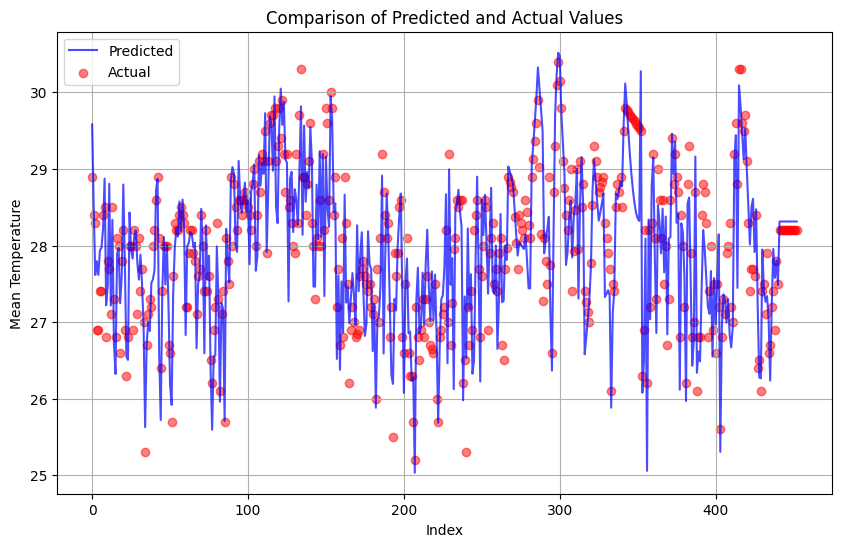

In [42]:
idx = [i for i in range(len(X_test))]  # Select every 100th index for plotting
plt.figure(figsize=(10, 6))
plt.plot(idx, y_pred, label="Predicted", color="blue", alpha=0.7)
plt.scatter(idx, y_test, label="Actual", color="red", alpha=0.5)
plt.title("Comparison of Predicted and Actual Values")
plt.xlabel("Index")
plt.ylabel("Mean Temperature")
plt.legend()
plt.grid()
plt.show()

## 📝 **Evaluation**

Karena data berupa time series, maka kita akan melakukan evaluasi dengan menggunakan Walk Forward Cross Validation.

Dimana data akan dibagi menjadi beberapa window dan akan dilakukan training pada window tersebut, kemudian dilakukan evaluasi pada data berikutnya.

In [43]:
def walk_forward_validation(data, train_size=100, test_size=1):
    r2_scores = []
    MAE = []
    MSE = []
    for i in range(len(data) - train_size - test_size + 1):
        train, test = data[i:i + train_size], data[i + train_size:i + train_size + test_size]

        X_train = train.drop(columns=['mean_temperature'])
        y_train = train['mean_temperature']

        X_test = test.drop(columns=['mean_temperature'])
        y_test = test['mean_temperature']

        # Lewati jika hanya 1 titik data test (agar R² valid)
        if len(y_test) < 2:
            continue

        model = PolynomialRegression()
        model.fit(X_train, y_train, order=2)

        
        evaluation = model.evaluate_all(X_test, y_test)
        r2_scores.append(evaluation['R2'])
        MAE.append(evaluation['MAE'])
        MSE.append(evaluation['MSE'])

    # Mendapatkan rata - rata dari hasil evaluasi setiap window
    print("Mean R2 Scores: {:.4f}".format(np.mean(r2_scores)))
    print("Mean MAE: {:.4f}".format(np.mean(MAE)))
    print("Mean MSE: {:.4f}".format(np.mean(MSE)))

In [44]:
walk_forward_validation(final_data, 400, 100)

Mean R2 Scores: 0.6883
Mean MAE: 0.4109
Mean MSE: 0.2810


Terlihat bahwa Polinomial Orde 2 cenderung memiliki nilai R2, MSE, dan MAE yang stabil untuk keseluruhan data

## 📈 **Prediksi Data Baru**

In [45]:
model = PolynomialRegression()
model.fit(X_train, y_train, 2)

# Membuat DataFrame baru untuk prediksi
data = {
    "daily_rainfall_total": [0.0],
    "maximum_temperature": [31.4],
    "minimum_temperature": [24.4],
    "mean_wind_speed": [11.7],
    "max_wind_speed": [38.2]
}

new_df = pd.DataFrame(data)

# Melakukan prediksi
print("Hasil prediksi = {:.4f}".format(model.getAllPrediction(new_df)[0]))

Hasil prediksi = 27.0657
